# Libraries

In [2]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
import joblib
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })

# Data upload

In [3]:
df = pd.read_excel('rccarbonation.xlsx')
df = df.rename(columns={'Possan': 'carb. depth (mm)'})
df = df.rename(columns={'CCO₂ (%)': 'CO2 (%)'})
df.head()

,CO2 (%),fc (MPa),RH (%),Type of cement,Exposure conditions,t (years),carb. depth (mm)
0,0.08,25.9,35.4,CPII Z,PIA,9,10.1384
1,0.07,21.7,43.8,CPV - ARI,UEA,92,23.2231
2,0.08,30.3,83.7,CPIV,UEA,58,13.2715
3,0.15,22.8,37.6,CPIV,PIA,42,45.1498
4,0.03,26.4,65.2,CPII F,UEA,96,22.6178


### Convert categorical text data to numeric codes 

In [4]:
mapping_dict = {
                    r'\bPIA\b': '0', r'\bUEA\b': '1', r'\bPEA\b': '2',
                    r'\bCPII Z\b': '0', r'\bCPV - ARI\b': '1', r'\bCPIV\b': '2',
                    r'\bCPII F\b': '3', r'\bCPIII\b': '4', r'\bCPII E\b': '5',
               }
df.replace(mapping_dict, regex=True, inplace=True)    
for col in ['Exposure conditions', 'Type of cement']:
    df[col] = pd.to_numeric(df[col])
df.head()

,CO2 (%),fc (MPa),RH (%),Type of cement,Exposure conditions,t (years),carb. depth (mm)
0,0.08,25.9,35.4,0,0,9,10.1384
1,0.07,21.7,43.8,1,1,92,23.2231
2,0.08,30.3,83.7,2,1,58,13.2715
3,0.15,22.8,37.6,2,0,42,45.1498
4,0.03,26.4,65.2,3,1,96,22.6178


# Train mutiple models with different random states to choose the best one

$n_{folds}$ = 10

In [5]:
random_states = [42, 7, 21, 35, 14, 28, 56, 63, 84, 91]   # Change as you wish

### Models

In [6]:
ia_models = {
                "LinearRegression": LinearRegression(),
                "Ridge": Ridge(),
                "Lasso": Lasso(),
                "DecisionTree": DecisionTreeRegressor(random_state=42),
                "RandomForest": RandomForestRegressor(random_state=42),
                "GradientBoosting": GradientBoostingRegressor(random_state=42),
                "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
            }

### Folder for saving models and split data

In [7]:
os.makedirs('models', exist_ok=True)

### Train

In [8]:
dict = {"LinearRegression train": [], "LinearRegression test": [], "Ridge train": [], "Ridge test": [], "Lasso train": [], "Lasso test": [], "DecisionTree train": [], "DecisionTree test": [], "RandomForest train": [], "RandomForest test": [], "GradientBoosting train": [], "GradientBoosting test": [], "HistGradientBoosting train": [], "HistGradientBoosting test": []}
for model_name, model in ia_models.items():
    print(f"Treinando {model_name}...")
    x = df.drop(columns=['carb. depth (mm)'])
    y = df['carb. depth (mm)']
    for i, state in enumerate(random_states):
        # Split the data
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=state)
        
        # Train the model
        model.fit(x_train, y_train)

        # Evaluate the model
        r2_train = r2_score(y_train, model.predict(x_train))
        r2_test = r2_score(y_test, model.predict(x_test))
        
        # Save results and model
        print(f'Fold {i+1}/{len(random_states)} - R² score in training: {r2_train:.3f} - R² score in testing: {r2_test:.3f}')
        dict[f"{model_name} train"].append(r2_train)
        dict[f"{model_name} test"].append(r2_test)
        model_filename = f'models/model_{model_name}_fold_{i+1}.pkl'
        joblib.dump(model, model_filename)
        
        # Save the data splits
        fold_data = {'metadata': f"This pkl contains the data splits",
            'x_train': x_train,
            'x_test': x_test,
            'y_train': y_train,
            'y_test': y_test
        }
        data_filename = f'models/fold_data_{model_name}_fold_{i+1}.pkl'
        joblib.dump(fold_data, data_filename)

Treinando LinearRegression...
Fold 1/10 - R² score in training: 0.543 - R² score in testing: 0.550
Fold 2/10 - R² score in training: 0.546 - R² score in testing: 0.539
Fold 3/10 - R² score in training: 0.545 - R² score in testing: 0.540
Fold 4/10 - R² score in training: 0.546 - R² score in testing: 0.538
Fold 5/10 - R² score in training: 0.547 - R² score in testing: 0.535
Fold 6/10 - R² score in training: 0.546 - R² score in testing: 0.535
Fold 7/10 - R² score in training: 0.543 - R² score in testing: 0.549
Fold 8/10 - R² score in training: 0.546 - R² score in testing: 0.538
Fold 9/10 - R² score in training: 0.542 - R² score in testing: 0.555
Fold 10/10 - R² score in training: 0.546 - R² score in testing: 0.537
Treinando Ridge...
Fold 1/10 - R² score in training: 0.543 - R² score in testing: 0.550
Fold 2/10 - R² score in training: 0.546 - R² score in testing: 0.539
Fold 3/10 - R² score in training: 0.545 - R² score in testing: 0.540
Fold 4/10 - R² score in training: 0.546 - R² score in

#### Final statistics

In [9]:
dict_df = pd.DataFrame(dict)
dict_df

,LinearRegression train,LinearRegression test,Ridge train,Ridge test,Lasso train,Lasso test,DecisionTree train,DecisionTree test,RandomForest train,RandomForest test,GradientBoosting train,GradientBoosting test,HistGradientBoosting train,HistGradientBoosting test
0,0.542581,0.550491,0.542581,0.550482,0.531256,0.536338,1.0,0.914298,0.994500,0.958347,0.950759,0.946825,0.995476,0.992224
1,0.545693,0.538720,0.545693,0.538719,0.533946,0.531589,1.0,0.921223,0.994674,0.963482,0.951087,0.940308,0.995595,0.992938
2,0.545371,0.539654,0.545371,0.539661,0.533886,0.532446,1.0,0.922733,0.994605,0.962320,0.948651,0.938852,0.995773,0.992730
3,0.545683,0.537903,0.545683,0.537915,0.534395,0.525137,1.0,0.918211,0.994598,0.965022,0.950827,0.944351,0.995765,0.993458
4,0.546533,0.534568,0.546533,0.534558,0.535446,0.526885,1.0,0.916498,0.994688,0.963717,0.951682,0.940681,0.995613,0.992531
5,0.546470,0.535380,0.546470,0.535375,0.534966,0.521657,1.0,0.920548,0.994716,0.964066,0.950755,0.944428,0.995515,0.992390
6,0.543030,0.549297,0.543030,0.549298,0.531772,0.540930,1.0,0.920483,0.994627,0.961377,0.951398,0.946450,0.995353,0.992546
7,0.545887,0.537913,0.545887,0.537914,0.534450,0.524690,1.0,0.913299,0.994435,0.959820,0.951176,0.940071,0.995735,0.992626
8,0.541856,0.554569,0.541856,0.554569,0.530845,0.544314,1.0,0.906986,0.994655,0.958334,0.951069,0.952604,0.995565,0.991777
9,0.546001,0.536965,0.546001,0.536972,0.534716,0.527156,1.0,0.918016,0.994708,0.966047,0.951769,0.944699,0.995916,0.993446


#### Best fold best model

In [10]:
best_fold = dict_df['HistGradientBoosting test'].idxmax()
print(f"Best fold for HistGradientBoosting: Fold {best_fold + 1} with R² score of {dict_df['HistGradientBoosting test'][best_fold]:.5f}")
name_best_model = f'models/model_HistGradientBoosting_fold_{best_fold + 1}.pkl'
name_best_fold_data = f'models/fold_data_HistGradientBoosting_fold_{best_fold + 1}.pkl'
print(f"\nLoading model from '{name_best_model}'")

Best fold for HistGradientBoosting: Fold 4 with R² score of 0.99346

Loading model from 'models/model_HistGradientBoosting_fold_4.pkl'


#### Plot in LateX

In [11]:
stats = dict_df.describe().T
stats = stats[['mean', 'std']]
stats

,mean,std
LinearRegression train,0.544911,0.001729
LinearRegression test,0.541546,0.007114
Ridge train,0.544911,0.001729
Ridge test,0.541546,0.007113
Lasso train,0.533568,0.001650
Lasso test,0.531114,0.007452
DecisionTree train,1.000000,0.000000
DecisionTree test,0.917230,0.004701
RandomForest train,0.994621,0.000091
RandomForest test,0.962253,0.002714


In [12]:
stt = stats.to_latex(float_format="%.2f")
print(stt)

\begin{tabular}{lrr}
\toprule
 & mean & std \\
\midrule
LinearRegression train & 0.54 & 0.00 \\
LinearRegression test & 0.54 & 0.01 \\
Ridge train & 0.54 & 0.00 \\
Ridge test & 0.54 & 0.01 \\
Lasso train & 0.53 & 0.00 \\
Lasso test & 0.53 & 0.01 \\
DecisionTree train & 1.00 & 0.00 \\
DecisionTree test & 0.92 & 0.00 \\
RandomForest train & 0.99 & 0.00 \\
RandomForest test & 0.96 & 0.00 \\
GradientBoosting train & 0.95 & 0.00 \\
GradientBoosting test & 0.94 & 0.00 \\
HistGradientBoosting train & 1.00 & 0.00 \\
HistGradientBoosting test & 0.99 & 0.00 \\
\bottomrule
\end{tabular}



# Predicted versus Observed plot for the best model and Worst model

### Load best model and predict

In [13]:
model = joblib.load(name_best_model)
x_test = joblib.load(name_best_fold_data)['x_test']
y_obs = joblib.load(name_best_fold_data)['y_test']
y_pred = model.predict(x_test)
data = pd.DataFrame({
                        "Observed": y_obs,
                        "Predicted": y_pred
                    })

### Plot best model

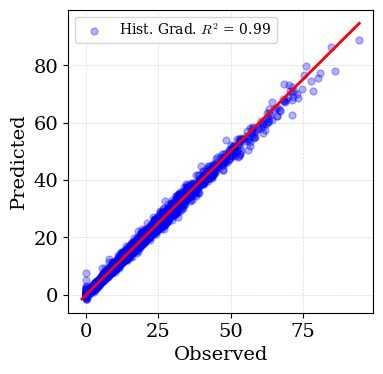

In [14]:
### Figure name and DPI
dpi = 600                                                   # Change as you wish
name = 'z_scatter_best_model'           # Change as you wish

### Chart dimensions (in centimeters)
b_cm = 10                                                    # Change as you wish
h_cm = 10                                                    # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels (For LateX font format use the dollar sign $)
label_x = 'Observed'                                        # Change as you wish
label_y = 'Predicted'                                       # Change as you wish
size_label = 14                                             # Change as you wish
color_label = 'black'                                       # or hexadecimal. Change as you wish
size_axis = 14                                              # Change as you wish
color_axis = 'black'                                        # or hexadecimal. Change as you wish

### Line
size_line = 2                                               # Change as you wish
style_line = '-'                                            # Change as you wish
color_line = 'red'                                          # or hexadecimal. Change as you wish

### Scatter
alpha_scatter = 0.3                                             # Change as you wish
color_scatter = 'blue'                                          # Change as you wish
size_scatter = 25                                               # Change as you wish

### Legend
labels_legend = f'Hist. Grad. $R^2$ = {dict_df["HistGradientBoosting test"][best_fold]:.2f}'                         # Change as you wish
size_legend = 10                                            # Change as you wish
location_legend = 'upper left'                              # Change as you wish - 'best' look up by the best fit

### Grid
on_or_off = True
line_width_grid = 0.5                                       # Change as you wish
alpha_grid = 0.3                                            # Change as you wish
style_grid = '--'                                            # Change as you wish
color_grid = 'gray'                                         # or hexadecimal. Change as you wish

# Max and min axis limits
lims = [
            min(data.min()),
            max(data.max())
        ]   

### Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

### Title. Do you need a title? Use the cell bellow:
# ax.set_title('Sine Wave Plot', fontsize=16)

### Config grid
plt.grid(on_or_off, which='both', linestyle=style_grid, linewidth=line_width_grid, color=color_grid, alpha=alpha_grid)

### Plot data and legend
ax.plot(lims, lims, linewidth=size_line, linestyle=style_line, color=color_line,)
ax.scatter(data["Observed"], data["Predicted"], alpha=alpha_scatter, color=color_scatter, s=size_scatter, label=labels_legend)
ax.legend(fontsize=size_legend, loc=location_legend)

### Save. Do you need save? Use the cell bellow:
fig.savefig(f'{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

### Load worst model and predict

In [15]:
worst_fold = dict_df['LinearRegression test'].idxmin()
print(f"Worst fold for LinearRegression: Fold {worst_fold + 1} with R² score of {dict_df['LinearRegression test'][worst_fold]:.5f}")
name_worst_model = f'models/model_LinearRegression_fold_{worst_fold + 1}.pkl'
name_worst_fold_data = f'models/fold_data_LinearRegression_fold_{worst_fold + 1}.pkl'
print(f"\nLoading model from '{name_worst_model}'")

Worst fold for LinearRegression: Fold 5 with R² score of 0.53457

Loading model from 'models/model_LinearRegression_fold_5.pkl'


In [16]:
model = joblib.load(name_worst_model)
x_test = joblib.load(name_worst_fold_data)['x_test']
y_obs = joblib.load(name_worst_fold_data)['y_test']
y_pred = model.predict(x_test)
data = pd.DataFrame({
                        "Observed": y_obs,
                        "Predicted": y_pred
                    })

### Plot worst model

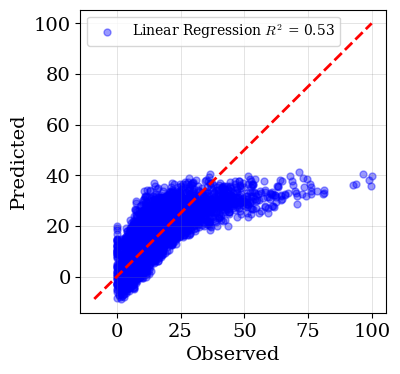

In [17]:
### Figure name and DPI
dpi = 600                                                   # Change as you wish
name = 'z_scatter_worst_model'           # Change as you wish

### Chart dimensions (in centimeters)
b_cm = 10                                                    # Change as you wish
h_cm = 10                                                    # Change as you wish
inches_to_cm = 1 / 2.54
b_input = b_cm * inches_to_cm
h_input = h_cm * inches_to_cm

### Axis and labels (For LateX font format use the dollar sign $)
label_x = 'Observed'                                        # Change as you wish
label_y = 'Predicted'                                       # Change as you wish
size_label = 14                                             # Change as you wish
color_label = 'black'                                       # or hexadecimal. Change as you wish
size_axis = 14                                              # Change as you wish
color_axis = 'black'                                        # or hexadecimal. Change as you wish

### Line
size_line = 2                                               # Change as you wish
style_line = '--'                                            # Change as you wish
color_line = 'red'                                          # or hexadecimal. Change as you wish

### Scatter
alpha_scatter = 0.4                                             # Change as you wish
color_scatter = 'blue'                                          # Change as you wish
size_scatter = 25                                               # Change as you wish

### Legend
labels_legend = f'Linear Regression $R^2$ = {dict_df["LinearRegression test"][worst_fold]:.2f}'                         # Change as you wish
size_legend = 10                                            # Change as you wish
location_legend = 'upper left'                              # Change as you wish - 'best' look up by the best fit

### Grid
on_or_off = True
line_width_grid = 0.5                                       # Change as you wish
alpha_grid = 0.3                                            # Change as you wish
style_grid = '-'                                            # Change as you wish
color_grid = 'gray'                                         # or hexadecimal. Change as you wish

# Max and min axis limits
lims = [
            min(data.min()),
            max(data.max())
        ]   

### Figure
fig, ax = plt.subplots(figsize=(b_input, h_input))
ax.tick_params(axis='both', which='major', labelsize=size_axis, colors=color_axis)
ax.set_xlabel(label_x, fontsize=size_label, color=color_label)
ax.set_ylabel(label_y, fontsize=size_label, color=color_label)

### Title. Do you need a title? Use the cell bellow:
# ax.set_title('Sine Wave Plot', fontsize=16)

### Config grid
plt.grid(on_or_off, which='both', linestyle=style_grid, linewidth=line_width_grid, color=color_grid, alpha=alpha_grid)

### Plot data and legend
ax.plot(lims, lims, linewidth=size_line, linestyle=style_line, color=color_line,)
ax.scatter(data["Observed"], data["Predicted"], alpha=alpha_scatter, color=color_scatter, s=size_scatter, label=labels_legend)
ax.legend(fontsize=size_legend, loc=location_legend)

### Save. Do you need save? Use the cell bellow:
fig.savefig(f'{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()